# 💻 Hands-On Lab Part 3 — Index Exploration vs. Radiative Transfer Models (45 Minutes)

In this final phase of the workshop, you will step away from guided scripts to conduct an independent algorithmic comparison. You will choose an advanced index, calculate its values across our farm's Area of Interest (AOI), and then evaluate your empirical satellite results against a simulated **Radiative Transfer (RT) Model**.

---

## 🔍 Step 1: Researching Alternative Indices

While NDVI and NDRE are highly popular, different crop characteristics require distinct spectral combinations. Review the table below, choose **one** index to focus on for your challenge, and analyze its structural advantages and trade-offs.

| Index Name | Sentinel-2 Spectral Recipe | Primary Advantage | Core Limitation / Disadvantage |
| :--- | :--- | :--- | :--- |
| **EVI** <br>*(Enhanced Vegetation Index)* | Uses Blue, Red, and NIR bands to adjust for atmospheric haze and soil background noise. | Excellent for high-biomass zones (forests/dense crops); **does not saturate** as easily as NDVI. | Highly sensitive to noise if the Blue band (`B02`) suffers from local sensor calibration errors. |
| **SAVI** <br>*(Soil-Adjusted Veg Index)* | Integrates a dynamic soil brightness correction factor ($L \approx 0.5$) into the NIR/Red matrix. | Crucial for **early-season emergence**; suppresses false backgrounds caused by bright or wet soil between rows. | Requires manually adjusting or assuming the soil correction factor ($L$), which varies by soil type. |
| **MSAVI** <br>*(Modified SAVI)* | Uses a self-adjusting math polynomial matrix instead of a static constant $L$ factor. | Completely automates soil correction; ideal for tracking **very sparse crops** or arid environments. | Computationally heavier and lacks a direct, intuitive linear physical scale. |
| **NDWI** <br>*(Normalized Diff. Water Index)* | Uses NIR (`B08`) and Shortwave Infrared (`B11` or `B12`). | Directly measures **canopy liquid water content** and crop water stress. | Can be easily confused by high soil moisture backgrounds if the crop canopy is open. |

---

## 🧪 Step 2: Student Challenge — Calculate Your Chosen Index

Using your chosen index from the matrix above, write the missing array algebra inside the execution block below. 

> ⚠️ **Compilation Rule:** Remember that different Sentinel-2 bands have different native pixel sizes. If your chosen index mixes $10\text{m}$ bands (like `B02`, `B04`, `B08`) with $20\text{m}$ bands (like `B11` or `B12`), you **must** use the `.rio.reproject_match()` protocol you learned in Part 2!

* **Action Required:** Complete the code snippet below for your selected index and plot the results.

In [2]:
# Uncomment the line below if you need to install the dependencies in your environment
# !pip install pystac-client pystac shapely planetary-computer requests matplotlib

import json
from pystac_client import Client
import planetary_computer as pc
from shapely.geometry import shape, mapping
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
import rioxarray



print("📦 Libraries imported successfully! Ready to connect to the datacube.")

# Define a bounding box around a high-production agricultural region
# Format: [min_longitude, min_latitude, max_longitude, max_latitude]
aoi_bbox = [13.15, 52.35, 13.18, 52.38] 

# Convert the bounding box into a standard GeoJSON geometry dictionary
aoi_geometry = {
    "type": "Polygon",
    "coordinates": [[
        [aoi_bbox[0], aoi_bbox[1]],
        [aoi_bbox[0], aoi_bbox[3]],
        [aoi_bbox[2], aoi_bbox[3]],
        [aoi_bbox[2], aoi_bbox[1]],
        [aoi_bbox[0], aoi_bbox[1]]
    ]]
}

print("Farm boundary geometry locked in. Ready to query.")


# Connect to the global cloud catalog endpoint
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

# Execute the programmatic search query
search = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=aoi_geometry,
    datetime="2025-04-01/2025-04-10", # Target spring growing season
    query={"eo:cloud_cover": {"lt": 10}} # Filter: less than 10% cloud cover
)

# Fetch all matching items found in the cloud registry
items = list(search.get_items())
print(f"📡 API Query Complete! Found {len(items)} cloud-free satellite scenes matching your criteria.")

s2_items = [pc.sign(item) for item in search.get_items()]
cropping_poly = shape(aoi_geometry)

print(f"📈 Analytics engine armed. Ready to process {len(s2_items)} multi-spectral scenes.")


Bad key keymap.all_axes in file matplotlibrc, line 398 ('keymap.all_axes : a                 # enable all axes')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


📦 Libraries imported successfully! Ready to connect to the datacube.
Farm boundary geometry locked in. Ready to query.


/root/.local/lib/python3.12/site-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


📡 API Query Complete! Found 4 cloud-free satellite scenes matching your criteria.
📈 Analytics engine armed. Ready to process 4 multi-spectral scenes.


In [3]:
def process_student_challenge_index(index_frame):
    if not s2_items:
        print("❌ No imagery layers found.")
        return
        
    current_item = s2_items[index_frame]
    
    try:
        # 📥 1. STREAM AND CLIP YOUR SPECIFIC BANDS
        # (Example below sets up basic bands; modify according to your chosen index)
        url_b08 = current_item.assets["B08"].href # NIR
        raster_b08 = rioxarray.open_rasterio(url_b08)
        clip_b08 = raster_b08.rio.clip([cropping_poly], crs="EPSG:4326", from_disk=True)
        nir = clip_nir = clip_b08.data[0].astype(float)
        
        url_b04 = current_item.assets["B04"].href # Red
        raster_b04 = rioxarray.open_rasterio(url_b04)
        clip_b04 = raster_b04.rio.clip([cropping_poly], crs="EPSG:4326", from_disk=True)
        red = clip_b04.data[0].astype(float)
        
        # NOTE: If you use a 20m band (like B11 for NDWI), uncomment and use this alignment block:
        # url_b11 = current_item.assets["B11"].href
        # raster_b11 = rioxarray.open_rasterio(url_b11)
        # clip_b11 = raster_b11.rio.clip([cropping_poly], crs="EPSG:4326", from_disk=True).rio.reproject_match(clip_b08)
        # swir = clip_b11.data[0].astype(float)

        # 🧮 2. WRITE YOUR SPECIFIC MATRIX ARITHMETIC HERE
        # ----------------------------------------------------
        # STUDENT TODO EXAMPLES:
        # For SAVI:  calculated_index = ((nir - red) / (nir + red + 0.5)) * 1.5
        # For NDWI:  calculated_index = (nir - swir) / (nir + swir + 1e-5)
        
        calculated_index = (nir - red) / (nir + red + 1e-5) # Placeholder default (NDVI)
        # ----------------------------------------------------
        
        # Render the custom output map
        plt.figure(figsize=(10, 8))
        img_plot = plt.imshow(calculated_index, cmap="viridis")
        plt.colorbar(img_plot, label="Custom Index Value")
        plt.title(f"🚀 Custom Research Index Assessment\n📅 Date: {str(current_item.datetime)[:16]}", fontsize=12, fontweight='bold')
        plt.axis("off")
        plt.show()
        
    except Exception as e:
        print(f"💥 Compilation error in your index math: {e}")

# Slider to scrub your custom calculation over time
if s2_items:
    widgets.interact(process_student_challenge_index, index_frame=widgets.IntSlider(min=0, max=len(s2_items)-1, step=1, value=0, description='Timeline:'))

interactive(children=(IntSlider(value=0, description='Timeline:', max=3), Output()), _dom_classes=('widget-int…

## 🤖 Step 3: Comparing Empirical Indices vs. Radiative Transfer Models

Empirical vegetation indices are useful shortcuts, but they do not account for the physics of light scattering. To achieve absolute precision, digital agronomists use **Radiative Transfer (RT) Models** like **PROSAIL**.

Instead of working backward from pixels to map crops, an RT model works *forward*. It takes physical parameters—such as Leaf Area Index ($LAI$), leaf chlorophyll content ($C_{ab}$), leaf water thickness ($C_m$), and solar viewing angles—and uses physics equations to simulate exactly what the reflectance spectrum *should* look like.



### 📊 Empirical Index vs. Physical RT Model Comparison Matrix

| Feature | Empirical Satellite Indices (NDVI, SAVI, etc.) | Radiative Transfer Models (PROSAIL) |
| :--- | :--- | :--- |
| **Underlying Approach** | **Statistical & Empirical:** Compares two or three broad light wavelengths. | **Physical Laws:** Models light ray interactions through individual canopy layers. |
| **Atmospheric Noise** | Highly susceptible to errors caused by atmospheric haze, dust, or clouds. | Mathematically isolates and accounts for atmospheric and solar angle interference. |
| **Saturation Limits** | **Saturates completely** once a canopy reaches full density, losing sensitivity. | Bypasses saturation boundaries by assessing multi-layer light scatter mechanics. |
| **Operational Goal** | Provides a rapid, relative indicator of crop vigor and spatial variation. | Inverts spectral data to map actual, physical properties (e.g., exact grams of nitrogen per leaf). |

---

## 📈 Step 4: Visualizing the Disconnect (Simulation Data Analysis)

Because executing a full multi-dimensional iterative PROSAIL numerical matrix inversion requires heavy background C-libraries (`prosail` Python package), we have provided a pre-calculated forward simulation dataset below. 

This model simulates a field growing over time, tracking how an empirical index changes compared to the true, physical Leaf Area Index ($LAI$) calculated by an RT model.

* **Action Required:** Run the simulation plotting cell below to visualize the performance gap.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Generic f

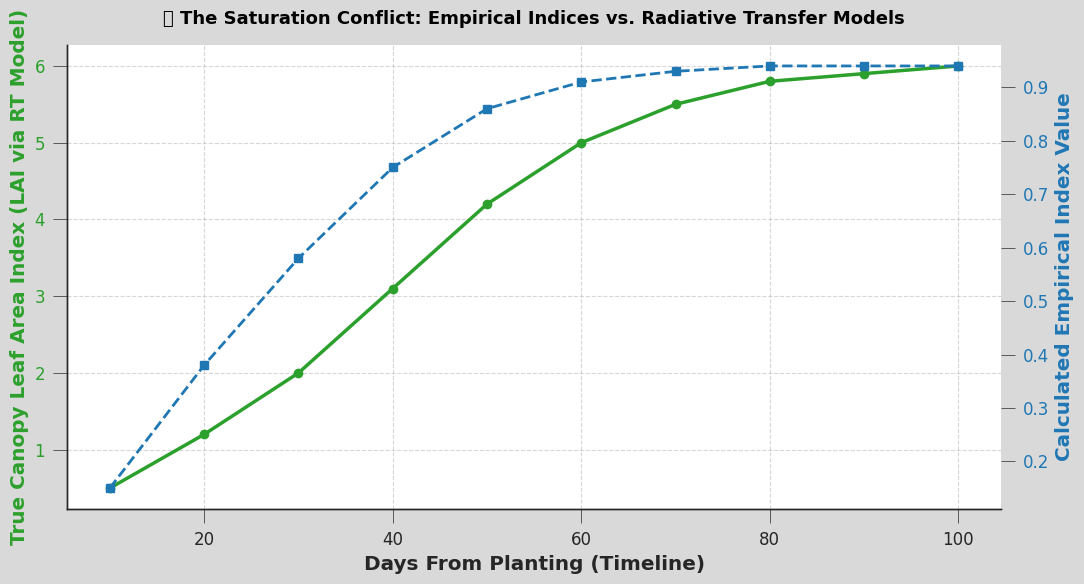

In [4]:
# Simulated Time Series Data tracking an expanding crop canopy
days_from_planting = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

# True physical leaf mass area scaling up linearly (Simulated by RT Model)
true_physical_lai = np.array([0.5, 1.2, 2.0, 3.1, 4.2, 5.0, 5.5, 5.8, 5.9, 6.0])

# What the empirical satellite index calculates (Simulated satellite curve showing saturation)
empirical_index_savi = np.array([0.15, 0.38, 0.58, 0.75, 0.86, 0.91, 0.93, 0.94, 0.94, 0.94])

# Plotting the analytical comparison deck
fig, ax1 = plt.subplots(figsize=(11, 6))

# Left Axis: True RT model parameters
color = 'tab:green'
ax1.set_xlabel('Days From Planting (Timeline)', fontweight='bold')
ax1.set_ylabel('True Canopy Leaf Area Index (LAI via RT Model)', color=color, fontweight='bold')
ax1.plot(days_from_planting, true_physical_lai, color=color, marker='o', linewidth=2.5, label='Physical LAI (RT Model)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Right Axis: Empirical index measurements
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Calculated Empirical Index Value', color=color, fontweight='bold')
ax2.plot(days_from_planting, empirical_index_savi, color=color, marker='s', linestyle='--', linewidth=2, label='Empirical Shortcut')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('🎯 The Saturation Conflict: Empirical Indices vs. Radiative Transfer Models', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

## 📝 Lab Assignment Report Questions

Based on your visual inspection of the simulation plot above, complete the following analysis in your final lab submission:

1. **The Saturation Horizon:** Look at what happens to the blue empirical curve after Day 60. While the green RT model curve proves the plants are still growing denser (Leaf Area Index increasing from $5.0$ to $6.0$), what does the empirical index do? Explain why this saturation creates an issue for late-season yield predictions.
2. **Operational Choice:** If you were managing a farm during **early-stage emergence (Days 10-30)**, why might an empirical index like SAVI be preferred over an expensive, complex RT model?